**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [3]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths LFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\logmel_segment_outputs\\logmel_train_set'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\logmel_segment_outputs\\logmel_dev_set'


**Preprocessing of training data** 

In [4]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-73.1337, -79.7413, -80.0000,  ..., -80.0000, -40.5297, -34.5130],
        [-68.8952, -75.8653, -79.2350,  ..., -80.0000, -39.6917, -33.5940],
        [-60.1044, -52.7878, -47.1181,  ..., -52.8543, -37.3541, -31.1615],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -37.1533, -43.9159, -58.7830],
        [-80.0000, -80.0000, -80.0000,  ..., -41.7762, -48.1216, -61.1447],
        [-80.0000, -80.0000, -80.0000,  ..., -50.6634, -56.2015, -65.2835]])
Example of the features tensor([[-68.2650, -73.0687, -80.0000,  ..., -80.0000, -53.5623, -48.9838],
        [-64.2337, -69.1971, -80.0000,  ..., -80.0000, -48.9756, -43.6622],
        [-57.0383, -59.2911, -65.3910,  ..., -47.2073, -42.8318, -39.5944],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -76.2001, -64.4199, -63.3450],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -70.4395, -68.6316],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -70.7288, -67.7301]])
Example of t

**Dataset inspection**

In [5]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([128, 126])
First sample values:
 tensor([[-73.1337, -79.7413, -80.0000,  ..., -80.0000, -40.5297, -34.5130],
        [-68.8952, -75.8653, -79.2350,  ..., -80.0000, -39.6917, -33.5940],
        [-60.1044, -52.7878, -47.1181,  ..., -52.8543, -37.3541, -31.1615],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -37.1533, -43.9159, -58.7830],
        [-80.0000, -80.0000, -80.0000,  ..., -41.7762, -48.1216, -61.1447],
        [-80.0000, -80.0000, -80.0000,  ..., -50.6634, -56.2015, -65.2835]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0])


**Testing the Data Loader**

In [6]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

128
torch.Size([25380, 128, 126])
Batch features shape: torch.Size([64, 128, 126])


**Preprocessing and loading the Development/Validation Set**

In [7]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-67.4962, -72.8796, -80.0000,  ..., -80.0000, -58.3227, -51.6387],
        [-59.4761, -64.8682, -80.0000,  ..., -80.0000, -51.9595, -45.7768],
        [-48.2820, -46.3185, -46.7214,  ..., -54.9564, -45.4795, -40.0990],
        ...,
        [-80.0000, -80.0000, -78.0606,  ..., -45.7424, -73.2229, -70.6072],
        [-80.0000, -80.0000, -78.9583,  ..., -48.8139, -72.6824, -69.0935],
        [-80.0000, -80.0000, -80.0000,  ..., -69.5045, -74.1996, -68.5529]])
Example of the features tensor([[-75.7218, -80.0000, -80.0000,  ..., -80.0000, -45.6055, -39.1818],
        [-72.0379, -78.4532, -80.0000,  ..., -69.2361, -44.2534, -38.0610],
        [-57.7454, -56.3686, -59.1783,  ..., -44.6239, -41.6526, -36.7544],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -38.4287, -42.1551, -47.1552],
        [-80.0000, -80.0000, -80.0000,  ..., -44.2059, -46.9943, -53.3000],
        [-80.0000, -80.0000, -80.0000,  ..., -47.0530, -51.0327, -56.9168]])
Example of t

**Testing the Processed Dataloaders and Label Distribution**

In [8]:
print("Training features shape",features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 128, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 128, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([63,  1])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [9]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [10]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=128, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = LFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification / previous line (before BCEwithLogits): x = torch.sigmoid(self.fc3(x))
        
        return x

**Initializing the model**

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [12]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_13156\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [13]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [14]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [15]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(model.state_dict(), 'saved_models/logmel_v5_best_model.pth')
    # Save the threshold to a file
        with open('saved_models/logmel_v5_best_threshold.txt', 'w') as f:
            f.write(str(best_threshold))
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/100] | Train Loss: 4.5603, Acc: 66.14% | Val Loss: 0.8583, Acc: 81.25% | Val EER: 36.06% | Val Threshold: -0.29%
Epoch [2/100] | Train Loss: 0.9394, Acc: 69.29% | Val Loss: 0.8410, Acc: 87.65% | Val EER: 29.40% | Val Threshold: -0.33%
Epoch [3/100] | Train Loss: 0.8880, Acc: 75.35% | Val Loss: 0.8390, Acc: 89.21% | Val EER: 30.05% | Val Threshold: -0.46%
EER not improved. Patience counter: 1/5
Epoch [4/100] | Train Loss: 0.8699, Acc: 78.72% | Val Loss: 0.8093, Acc: 89.44% | Val EER: 27.20% | Val Threshold: -0.47%
Epoch [5/100] | Train Loss: 0.8483, Acc: 80.04% | Val Loss: 0.7790, Acc: 89.52% | Val EER: 25.14% | Val Threshold: -0.54%
Epoch [6/100] | Train Loss: 0.8379, Acc: 80.28% | Val Loss: 0.7543, Acc: 88.96% | Val EER: 23.22% | Val Threshold: -0.42%
Epoch [7/100] | Train Loss: 0.8036, Acc: 80.67% | Val Loss: 0.7293, Acc: 85.41% | Val EER: 21.14% | Val Threshold: -0.23%
Epoch [8/100] | Train Loss: 0.7824, Acc: 81.41% | Val Loss: 0.7079, Acc: 84.07% | Val EER: 20.40% | Val Th

In [56]:
print(threshold_val)

-2.0188966


**Plotting the results**

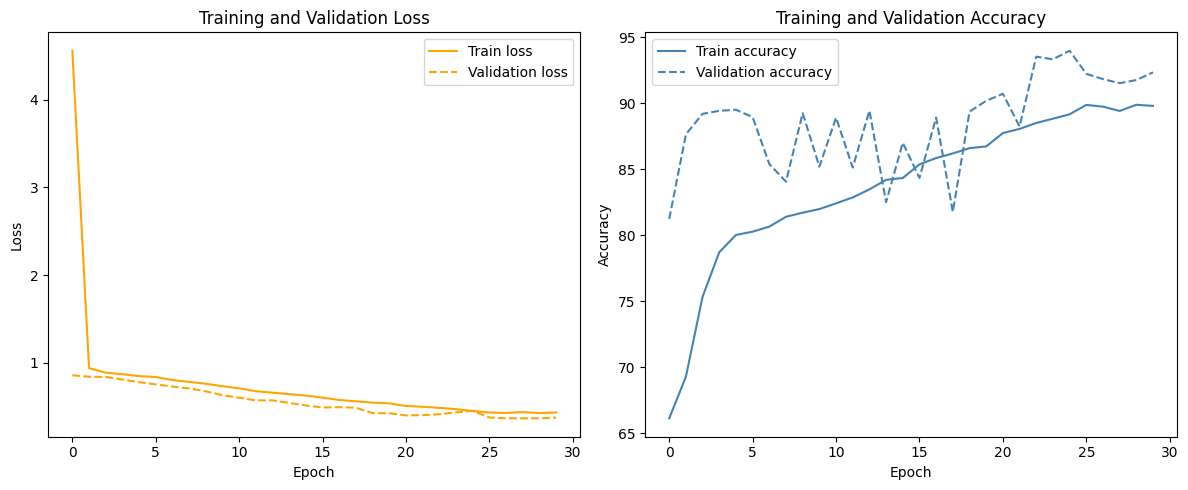

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model** (Actually don't do it, use the version saved in early stopping)

In [ ]:
# Save weights only
#torch.save(model.state_dict(), 'lfcc_with_delta_v3_updated_model_deepfake_audio_detection_model.pth')

# Save the full model (architecture + weights)
#torch.save(model, 'lfcc_with_delta_v2_updated_model_deepfake_audio_detection_model_full.pt')

**Prepare Evaluation Dataset**

In [17]:
# Evaluation
eval_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\logmel_segment_outputs\\logmel_eval_set'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-62.1734, -68.0007, -76.0866,  ..., -79.4794, -38.8465, -33.6564],
        [-57.5172, -62.3268, -62.0071,  ..., -65.9281, -36.0423, -30.9500],
        [-39.5689, -30.4846, -28.0631,  ..., -21.2953, -21.2519, -21.0322],
        ...,
        [-80.0000, -80.0000, -72.5668,  ..., -79.3929, -76.8564, -72.9511],
        [-80.0000, -80.0000, -76.8901,  ..., -80.0000, -75.6870, -71.7574],
        [-80.0000, -80.0000, -79.8556,  ..., -80.0000, -76.5156, -73.3206]])
Example of the features tensor([[-70.9154, -76.7733, -80.0000,  ..., -80.0000, -65.3454, -59.9487],
        [-66.5662, -72.3356, -73.8299,  ..., -65.9017, -61.5725, -54.7933],
        [-54.1044, -48.2736, -40.1013,  ..., -34.1690, -37.7402, -42.8825],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -79.9873,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]])
Example of t


Evaluation Set:
Loss: 0.5095 | Accuracy: 83.71%
EER: 16.61% | Logit Threshold: -0.0440 | Prob Threshold: 0.4890
F1 Score: 0.5089
Precision: 0.3662
Recall: 0.8339
Predictions: [1]: 16747 | [0]: 54490


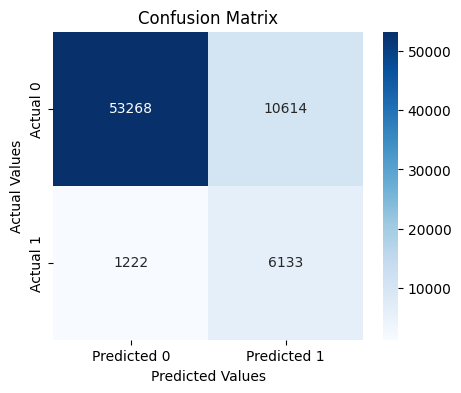

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)